In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Notebook Summary
This notebook has all the sequential operations done on a dataset for gold prices with features like (high, close, low, rsi, macd, bb's, etc...). This notebook employs 3 strategical operations :-
* Data Exploration
* Feature Selection and Engineering
* Model Creation and Comparison for Exact Price Prediction (Linear Regression and Random Forest)

In [22]:
#Importing Libraries and Essential Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [23]:
#Importing dataset
from gold_price_ds.dataset import *

data = load_raw_data()

print(data.to_string())

              adj close        close         high          low         open  volume         ma_7        ma_30        ma_90  daily_return  volatility_7  volatility_30        rsi        macd  macd_signal     bb_upper     bb_lower
date                                                                                                                                                                                                                               
2021-06-11  1877.400024  1877.400024  1902.300049  1875.199951  1900.900024     349  1887.828561  1860.180005  1790.618891     -0.008869      0.009353       0.007538  54.722931   19.724030    24.933953  1918.242879  1853.797124
2021-06-14  1864.000000  1864.000000  1866.599976  1846.500000  1866.199951      41  1886.799997  1863.403337  1790.972225     -0.007138      0.006411       0.007711  49.391919   16.433420    23.233846  1913.119794  1861.530206
2021-06-15  1854.500000  1854.500000  1867.199951  1854.400024  1866.400024      78  188

In [24]:
#Searching for missing values
data.isna().sum()

adj close        0
close            0
high             0
low              0
open             0
volume           0
ma_7             0
ma_30            0
ma_90            0
daily_return     0
volatility_7     0
volatility_30    0
rsi              0
macd             0
macd_signal      0
bb_upper         0
bb_lower         0
dtype: int64

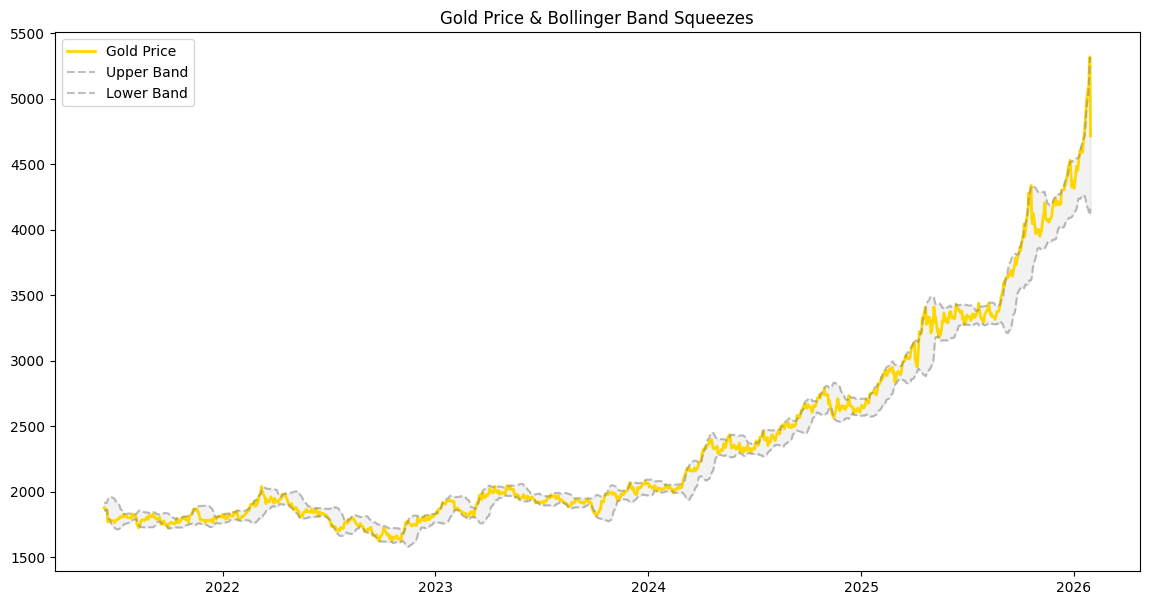

In [25]:
#Visualizing the Gold Price is respect to the bands
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['close'], label='Gold Price', color='gold', linewidth=2)
plt.plot(data.index, data['bb_upper'], label='Upper Band', color='gray', linestyle='--', alpha=0.5)
plt.plot(data.index, data['bb_lower'], label='Lower Band', color='gray', linestyle='--', alpha=0.5)

plt.fill_between(data.index, data['bb_lower'], data['bb_upper'], color='gray', alpha=0.1)
plt.title("Gold Price & Bollinger Band Squeezes")
plt.legend()
plt.show()

In [26]:
#Checking for Correlation towards my target variable
corrs = data.corr()["close"].sort_values(ascending=False)
print(corrs)

adj close        1.000000
close            1.000000
low              0.999801
high             0.999363
open             0.999166
ma_7             0.998617
bb_upper         0.997097
ma_30            0.995413
bb_lower         0.992017
ma_90            0.990971
macd_signal      0.754762
macd             0.738666
volatility_30    0.526533
rsi              0.429070
volatility_7     0.376799
daily_return     0.096007
volume           0.013694
Name: close, dtype: float64


### Correlation Analysis
As we can see from the correlation to the target, closing price. There are many features that have a near perfect correlation (0.99+). Models will lean heavily on those and having so many highly correlated values is just more clutter and noise for the model as they tell the same story. Therefore we reduce the number of features and select only the essential features like close, volume and ma_90, and the signaling features like macd_signal, rsi and volatility.

In [27]:
#Selecting the most important Features
selected_features = ['close', 'ma_90', 'macd_signal', 'volatility_30', 'rsi', 'volume']

data = data[selected_features]

print(data.columns)

Index(['close', 'ma_90', 'macd_signal', 'volatility_30', 'rsi', 'volume'], dtype='str')


In [28]:
#Creating Lagged features and Feature engineering
for i in [1, 2, 3]:
    data[f'close_lag_{i}'] = data['close'].shift(i)

data['target_price'] = data['close'].shift(-1)

data.dropna(inplace=True)

In [29]:
#Checking for Skewness if the dataset with selected features
print(data.skew())

close            1.438313
ma_90            1.355064
macd_signal      1.502502
volatility_30    1.661008
rsi              0.041809
volume           7.038429
close_lag_1      1.424307
close_lag_2      1.409851
close_lag_3      1.401108
target_price     1.437958
dtype: float64


In [30]:
#Fixing the skewness of all requires fields
skewed_cols = ['close', 'ma_90', 'macd_signal', 'volatility_30', 'volume',
       'close_lag_1', 'close_lag_2', 'close_lag_3', 'target_price']

#Using Log Transform to reduce the skewness of the data especially for Volume
for col in skewed_cols:
    data[col] = np.log1p(data[col])

data = data.dropna()

print("New Skewness Report")
print(data.skew())

New Skewness Report
close            0.647796
ma_90            0.618871
macd_signal     -0.990415
volatility_30    1.593843
rsi              0.073085
volume           0.255407
close_lag_1      0.642672
close_lag_2      0.637077
close_lag_3      0.634055
target_price     0.645777
dtype: float64


c:\Users\Srujan Bali\Documents\Srujan\Programming\Data Science\Gold_Price_DS\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
#Splitting the dataset into Training and Testing datasets
X = data.drop(columns=['target_price'])
y = data['target_price']

tscv = TimeSeriesSplit(n_splits=5)  #TimeSeriesSplit for chronologically splitting the data than randomly shuffling using train_test_split.

for train_index, test_index in tscv.split(X):
    x_train, x_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [32]:
#Creating a Linear Regression Model (Baseline Model)
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

lr_pipeline.fit(x_train, y_train)

lr_predictions = lr_pipeline.predict(x_test)

y_test_real = np.expm1(y_test)  #This is done to convert the log transformed values back to dollar values for better visualization
lr_preds_real = np.expm1(lr_predictions)   #This is done to convert the log transformed values back to dollar values for better visualization

#Metrics for the Base Line Linear Regression Model
lr_mae = mean_absolute_error(y_test_real, lr_preds_real)
lr_mse = mean_squared_error(y_test_real, lr_preds_real)
lr_rmse = np.sqrt(lr_mse)
lr_mape = mean_absolute_percentage_error(y_test_real, lr_preds_real)

print("Metrics for the Linear Regression Model")
print("MAE :- ", lr_mae)
print("RMSE :- ", lr_rmse)
print("MAPE :- ", lr_mape)

Metrics for the Linear Regression Model
MAE :-  44.036405767733925
RMSE :-  78.85151727581184
MAPE :-  0.010588127813952644


Text(0.5, 1.0, 'Predictions vs Actual Prices (Linear Regression)')

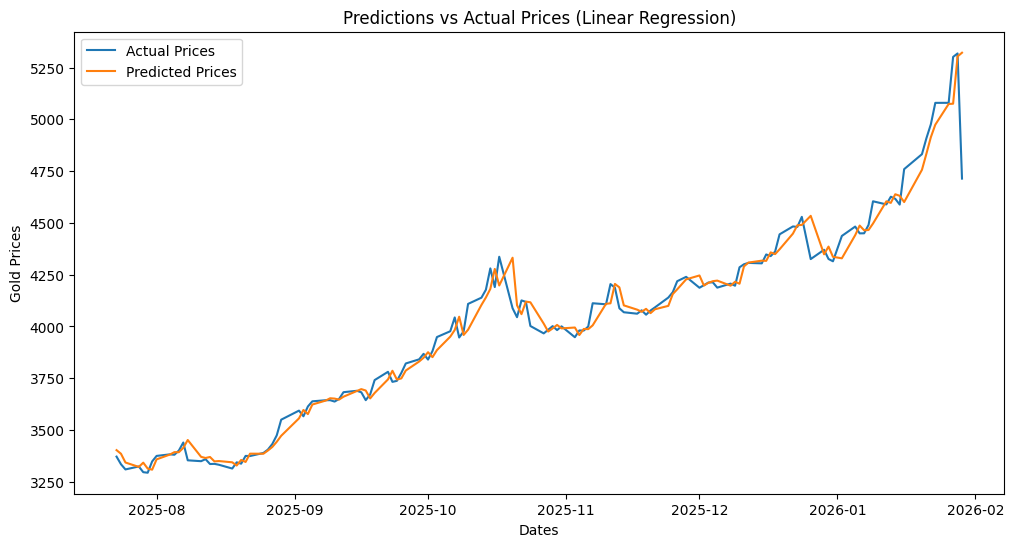

In [33]:
#Plotting the Prediction vs Actual Graph for Linear Regression Model
lr_results = pd.DataFrame({
    "Actual": y_test_real,
    "Predictions" : lr_preds_real
}, index=y_test_real.index)

plt.figure(figsize=(12, 6))
sns.lineplot(x=lr_results.index,  y=lr_results["Actual"], label="Actual Prices")
sns.lineplot(x=lr_results.index,  y=lr_results["Predictions"], label="Predicted Prices")
plt.xlabel("Dates")
plt.ylabel("Gold Prices")
plt.title("Predictions vs Actual Prices (Linear Regression)")

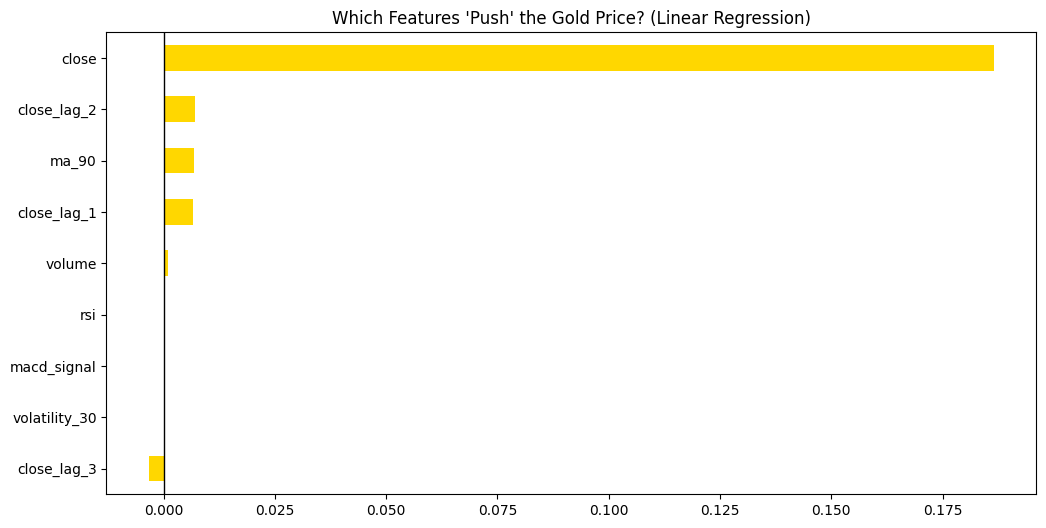

In [34]:
#Testing feature importance for the Linear Regression Model (Visualization)

lr_model = lr_pipeline.named_steps["lr"]

importance = pd.Series(lr_model.coef_ , index=X.columns )

plt.figure(figsize=(12, 6))
importance.sort_values().plot(kind='barh', color='gold')
plt.axvline(0, color='black', lw=1) # The "Zero" line
plt.title("Which Features 'Push' the Gold Price? (Linear Regression)")
plt.show()

### Linear Regression Analysis
From the test results of the Linear Regression Model we can see that it is fairly accurate and having it's predictions off by 44 dollars on average. Even though its metrics are flashy and super close it's just following a trend and not actually learning from the other features and soley determining the price of close and other lagged close values. This cannot be helped further than this due to the lack of necessary features in the dataset like US Dolllar Index, Silver Index, Interest Rates and other Stock Market Indices.

In [35]:
#Checking for the Directional Accuracy of Random Forest Regression Model
pred_move_log = np.where(lr_predictions > x_test['close'].values, 1, 0)

actual_move_log = np.where(y_test.values > x_test['close'].values, 1, 0)

# 3. Calculate Accuracy
directional_accuracy_log = np.mean(pred_move_log == actual_move_log)

print(f"Directional Accuracy : - {directional_accuracy_log:.2%}")

Directional Accuracy : - 63.64%


In [36]:
#Creating a Random Forest Model for further imporvement from baseline model
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=10, max_depth = 4))
])

rf_pipeline.fit(x_train, y_train)

rf_predictions = rf_pipeline.predict(x_test)
rf_preds_real = np.expm1(rf_predictions)

#Testing Metrics for this model
rf_mae = mean_absolute_error(y_test_real, rf_preds_real)
rf_mse = mean_squared_error(y_test_real, rf_preds_real)
rf_rmse = np.sqrt(rf_mse)
rf_mape = mean_absolute_percentage_error(y_test_real, rf_preds_real)

print(x_train.columns)

print("Metrics for the Random Forest Regression Model")
print("MAE :- ", rf_mae)
print("RMSE :- ", rf_rmse)
print("MAPE :- ", rf_mape)

Index(['close', 'ma_90', 'macd_signal', 'volatility_30', 'rsi', 'volume',
       'close_lag_1', 'close_lag_2', 'close_lag_3'],
      dtype='str')
Metrics for the Random Forest Regression Model
MAE :-  664.7708586075945
RMSE :-  809.4211421678996
MAPE :-  0.1550676181012763


Text(0.5, 1.0, 'Predictions vs Actual Prices (Random Forest)')

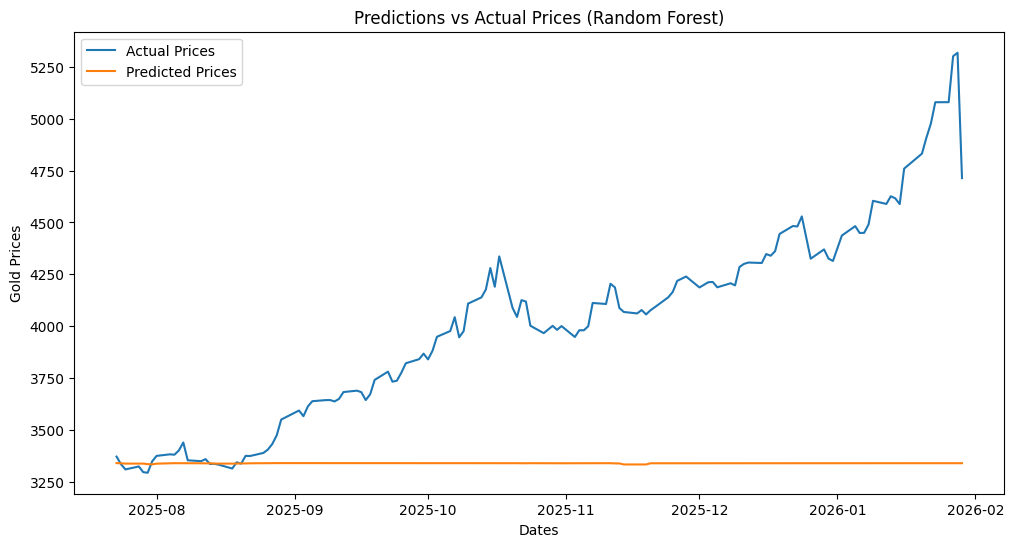

In [37]:
#Plotting the Prediction vs Actual Graph for Random Forest Regression Model
rf_results = pd.DataFrame({
    "Actual": y_test_real,
    "Predictions" : rf_preds_real
}, index=y_test_real.index)

plt.figure(figsize=(12, 6))
sns.lineplot(x=rf_results.index,  y=rf_results["Actual"], label="Actual Prices")
sns.lineplot(x=rf_results.index,  y=rf_results["Predictions"], label="Predicted Prices")
plt.xlabel("Dates")
plt.ylabel("Gold Prices")
plt.title("Predictions vs Actual Prices (Random Forest)")

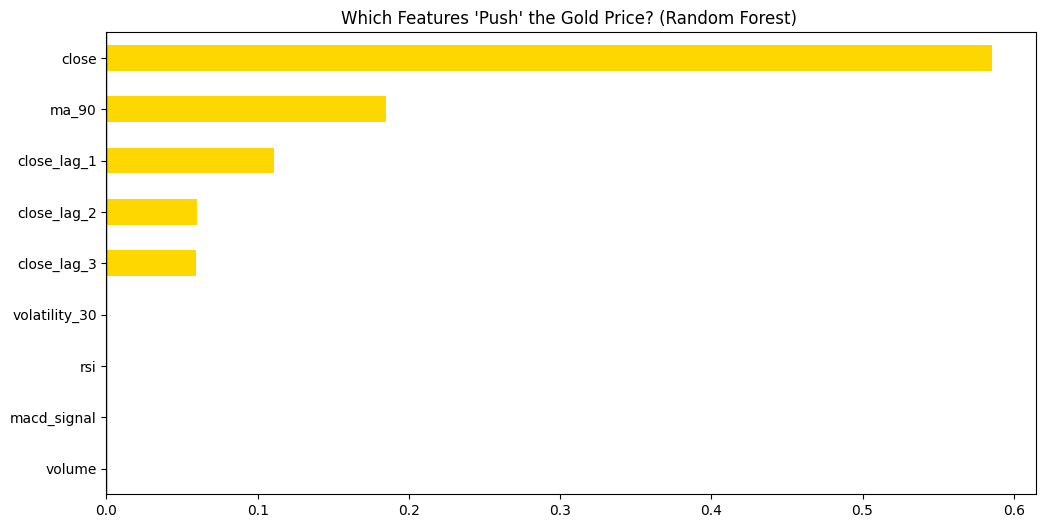

In [38]:
#Testing feature importance for the Random Forest Regression Model (Visualization)

rf_model = rf_pipeline.named_steps["rf"]

importance = pd.Series(rf_model.feature_importances_ , index=X.columns )

plt.figure(figsize=(12, 6))
importance.sort_values().plot(kind='barh', color='gold')
plt.axvline(0, color='black', lw=1) # The "Zero" line
plt.title("Which Features 'Push' the Gold Price? (Random Forest) ")
plt.show()

In [39]:
#Checking for the Directional Accuracy of Random Forest Regression Model
pred_move_log = np.where(rf_predictions > x_test['close'].values, 1, 0)

actual_move_log = np.where(y_test.values > x_test['close'].values, 1, 0)

# 3. Calculate Accuracy
directional_accuracy_log = np.mean(pred_move_log == actual_move_log)

print(f"Directional Accuracy : - {directional_accuracy_log:.2%}")

Directional Accuracy : - 37.12%


### Random Forest Regression Analysis
Random Forest is likely predicting worse due to the unability to extrapolate from the training data it got. The prediction line never leaves the 3300 mark cause maybe the training data didnt have values as large as 5000 therefore it has a ceiling it cannot break. Linear Regression is better at predicting and giving a closer exact price due to the change is data being gradual the tomorrow's price is likey closer to today's price.

This ceiling can be dealt with if we use Random Forest to give us daily returns rather than the exact price of gold tomorrrow. This new model is created in this project in another notebook.